In [1]:

import iree
import iree.compiler
import iree.runtime
import torch
import numpy as np
from torch import nn
from torchvision import models

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

BENCHMARK_REPEAT=111
df = pd.DataFrame()

arg0 = torch.randn(1, 7, 7, 512)
arg0_np = arg0.detach().cpu().numpy()
arg1 = torch.randn(512, 3, 3, 512)
arg1_np = arg1.detach().cpu().numpy()
arg2 = torch.randn(512, 3, 3, 512)
arg2_np = arg2.detach().cpu().numpy()

In [2]:
# v1, transpose-conv-transpose => conv, if transpose can eliminate
# avgpool 7x7x512, 1x1x512 => reshape 49x512, reduce_sum
model_file = "tune_partial_fusion_conv.mlir"
target_file = model_file + ".pfuse"

!iree-compile {model_file} \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86 \
-o {target_file}.vmfb

baseline = target_file+".vmfb"

def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo
baseline_fb = load_executable(baseline)

In [3]:
f1 = timeit("baseline_fb.fuse_conv_pair(arg0_np, arg1_np, arg2_np)") / BENCHMARK_REPEAT
print('forward in timeit: ', f1)
data = pd.DataFrame({
            "time": f1,
            "pass": "Time",
            "item": "Conv-Pair-Fuse::Baseline"
        }, index=[0])
df = pd.concat([df, data])
print(df)

forward in timeit:  0.6981430104556116
       time  pass                      item
0  0.698143  Time  Conv-Pair-Fuse::Baseline


In [12]:
#Q!iree-compile {target_file}.executable-configurations \
!iree-compile {model_file}.legal \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86 \
-o {target_file}.vmfb.optimised

optimised = target_file+".vmfb.optimised"
optimised_fb = load_executable(optimised)

In [13]:
f1 = timeit("optimised_fb.fuse_conv_pair(arg0_np, arg1_np, arg2_np)") / BENCHMARK_REPEAT
print('forward in timeit: ', f1)
data = pd.DataFrame({
            "time": f1,
            "pass": "Time",
            "item": "Conv-Pair-Fuse::Optimised"
        }, index=[0])
df = pd.concat([df, data])
print(df)

forward in timeit:  2.2949095219709315
       time  pass                       item
0  0.698143  Time   Conv-Pair-Fuse::Baseline
0  1.465740  Time  Conv-Pair-Fuse::Optimised
0  2.294910  Time  Conv-Pair-Fuse::Optimised


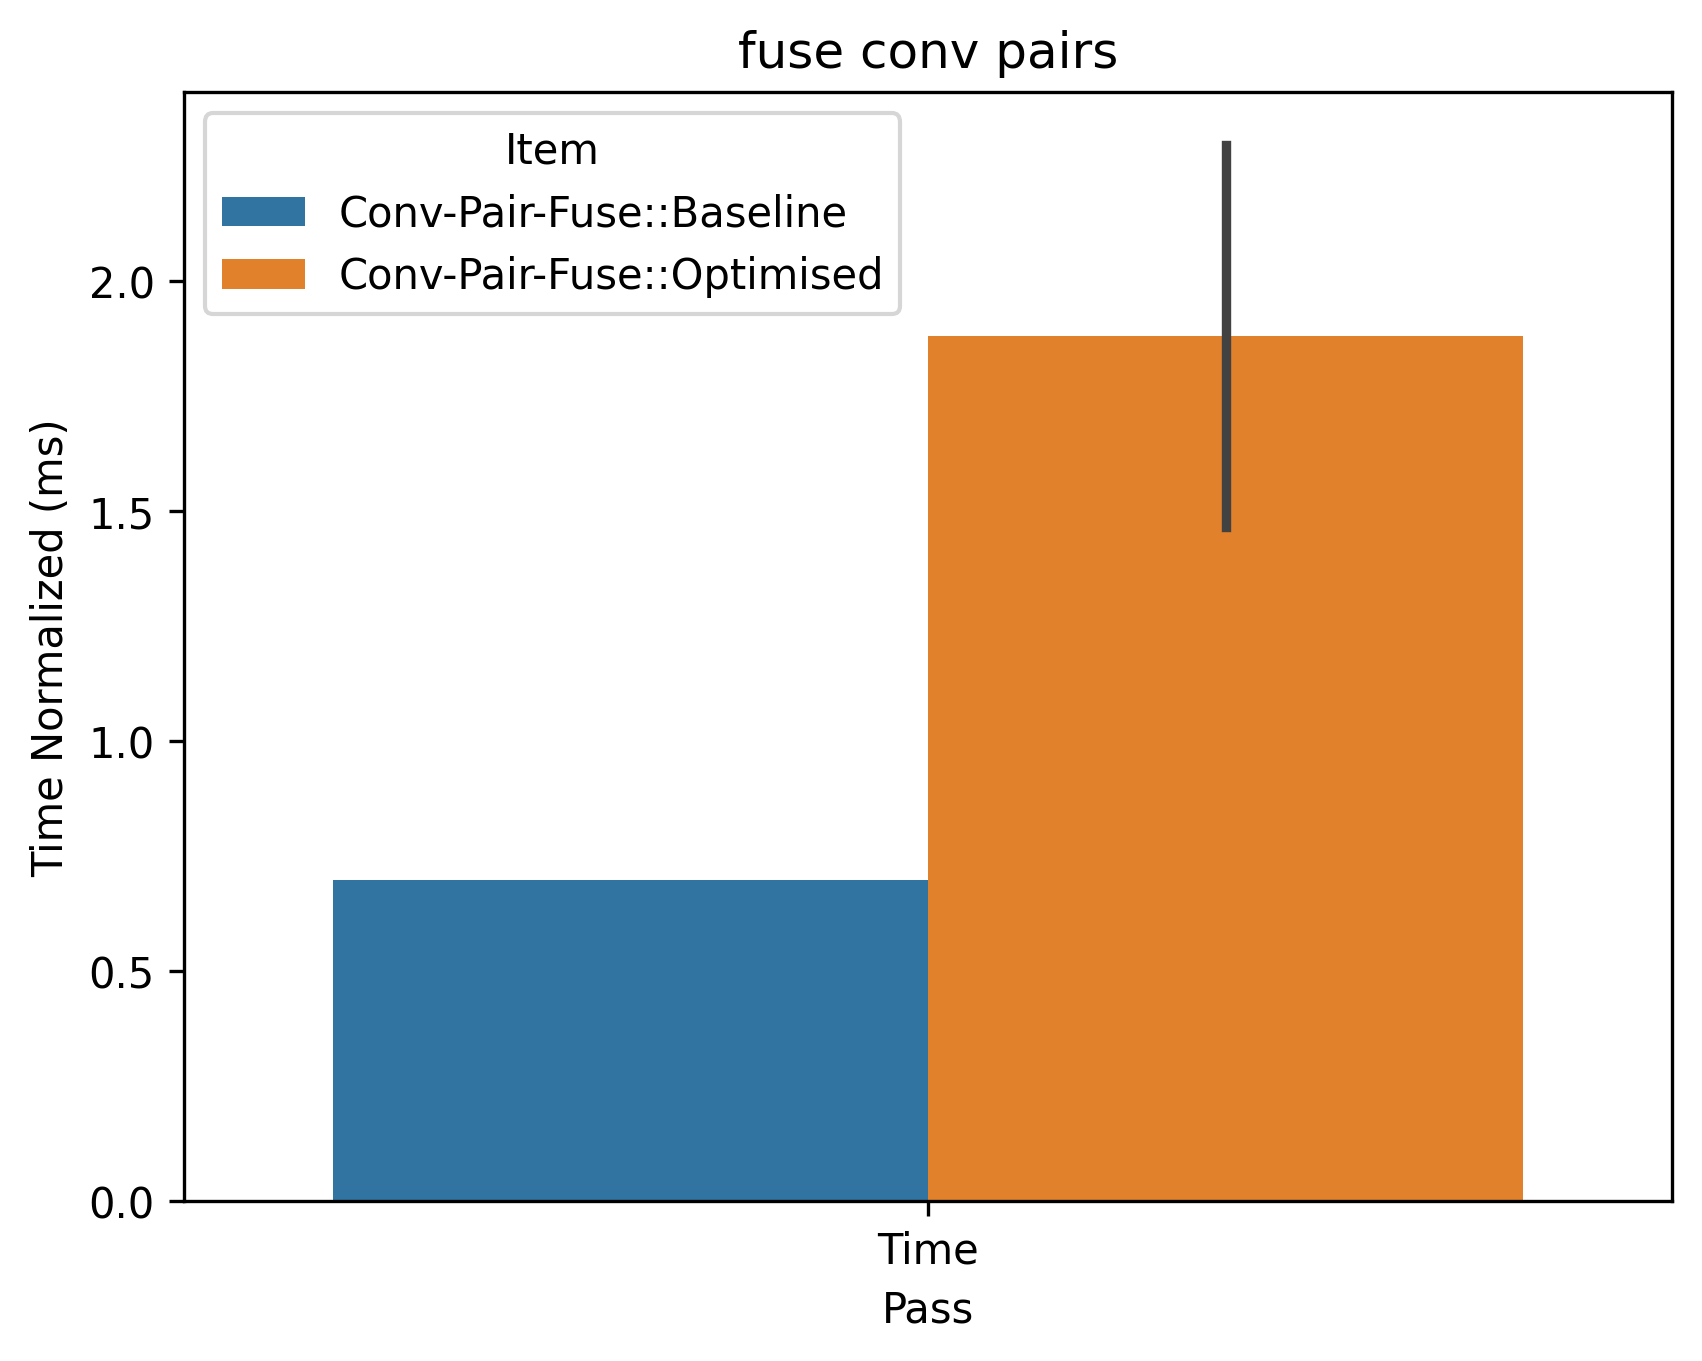

In [14]:
df.style.hide(axis="index")
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title("fuse conv pairs")

plt.savefig(f"fuse conv pairs-time.png")